# Prediction with Machine Learning

#### Student Name: [Aditi Bhat]

## Task description

<b>Main task</b>: Choose <b>one</b> of the following datasets. Build a linear regression model and another machine learning model of your choice to conduct predictions on future new unseen data. Use approporate methods in pandas, matplotlib and sklearn libraries to analyse and process your dataset for building models for your chosen prediction task.
- Movies_Ratings: predict movie ratings
- Shared_Bike_Demand: predict bike sharing demand
- Forest_Fires_Area: predict areas of forest fires
- Obesity_Level: predict level of obesity

<div class="alert alert-success" style="text-align:left;">
<h2>Question 1. Prediction Model 1 - Linear Regression Model<span style="float:right;">[50 marks]</span></h2></div>

#### Question 1a <span style="color:red">(5 marks)</span> 
Briefly explain the characteristics of the dataset that make it suitable for regression analysis. Your justification should demonstrate your understanding of the linear regression model.

<b>Q1a Answer</b>: I have chosen the Forest_Fires_Area dataset. 

The dataset contains several numeric variables such as 'moisture_shade', 'moitsture_litter', 'soil_dryness', 'spread_rate', 'temperature', 'humidity','wind(kmh)', 'rain(mm)' and so on. These variables represent the various environmental factors that can affect the cause of forest fires. Linear regression works well when using numeric variables, hence these features (mostly independent variables) can be used in the regression analysis. 

The target variable: 'area', represents the area affected by the fire and it is a continuous variables, and linear regression is suitable for predicting continuous outcomes. 

During regression analysis, the performance can be evaluated using the Mean Squared Error (MSE) which measures the average squared difference between the actual and predicted values of the target variables. A lower MSE implies the model's predictions are closer to the actual values indicating better performance and vice versa. This can allow the assesment of how well the linear regression model fits the data and predicts the area affected by the forest fires based on the environmental factors.

Lastly, the dataset has a variety of feature values which suggests that there is ample and sufficient data for training a reliable linea regression model. This can allow us to analyse, understand and interpret the patterns and identify the relationships between the predictors and target variables with greater accuracy.



In [1]:
# import approporate libraries
import pandas as pd #data preparation
import numpy as np #data visualisation
import matplotlib.pyplot as plt

#Load the dataset
path_to_file = "Forest_Fires_Area.csv"
data = pd.read_csv(path_to_file)
data.describe()

,coordinate_x,coordinate_y,moisture_shade,moisture_litter,soil_dryness,spread_rate,temperature,humidity,wind(kmh),rain(mm),area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,515.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.295146,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.323763,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


#### Question 1b <span style="color:red">(15 marks)</span>
Use approporate methods in pandas and/or matplotlib libraries to analyse your dataset. Are there issues you observe in which part(s) of the data? What would happen if the data is not pre-processed properly?

<b>Q1b answer</b>:

1. Missing Values

Missing values in the dataset can introduce bias and affect the accuracy of the analysis. This dataset contains some missing values. Column 'day' has four missing values. Column 'humidity' has four missing values.

2. Categorical Variables

The columns 'month' and 'day' represent categorical variables. They need to be converted into a format suitable for regression analysis. Regression models typically require numerical inputs, so these categorical variables could be encoded properley or could be dropped from the dataset. 

3. Variable Scaling

Variables with higher standard deviations and ranges have a larger variablitiy in their values and may influence the regression model's parameters more than the variables with smaller standard deviations and ranges.

The variables in the dataset have different scales:
'moisture_shade', 'moisture_litter', 'soil_dryness' and 'area' have relatively small values.
'spread_rate', 'temperature', 'humidity', 'wind(kmh)' and 'rain(mm)' have larger ranges.
Variable scaling is crucial for regression analysis, especially when the variables have different scales. This can improve the convergence of the regression algorithm and ensure that each variable contributes proportionally to the model's predictions.

4. Outliers

Outliers can skew the results of regression analysis. 
They can deviate significantly from the rest of the data and can have a disproportionate impact on the regression coefficients and predictions. The boxplot below shows that there are a significant amount of outliers in the dataset which need to be addressed.



5. If the data is not preprocessed properley then several consequences may occur such as:

-Biased results - missing values or outliers can lead to inaccurate estimates of the relationships between predictors and the target variable
-Incorrect interpretations - wrong handling of categorical variables without encoding them may result in incorrect
-Interpretations of their effects on the target variable
-Model instablitiy - variables with different scales will lead to difficulties in convergence during the optimization process
-Deceased predictive performance - failure to preprocess the data appropriately can result in lower predictive accuracy on new, unseen data

In [2]:
#Missing Values
print(" ")
print("1. Missing values")
print(" ")
print(data.isnull().sum())
print(" ")

 
1. Missing values
 
coordinate_x       0
coordinate_y       0
month              0
day                4
moisture_shade     0
moisture_litter    0
soil_dryness       0
spread_rate        0
temperature        0
humidity           2
wind(kmh)          0
rain(mm)           0
area               0
dtype: int64
 


In [3]:
#Categorical data
print(" ")
print("2. Categorical data")
print(" ")
categorical_columns = data.select_dtypes(include=['object']).columns
print(categorical_columns)
print(" ")

 
2. Categorical data
 
Index(['month', 'day'], dtype='object')
 


In [4]:
#Variable Scaling
print(" ")
print("3. Variable Scaling")
print(" ")

# Calculate and display the ranges of the variables
print("Ranges of the variables:")
print(" ")
ranges = data.max(numeric_only=True) - data.min(numeric_only=True)
print(ranges)
print(" ")

# Calculate and display the standard deviations of the variables
print("\nStandard deviations of the variables:")
print(" ")
std_devs = data.std(numeric_only=True)
print(std_devs)
print(" ")

 
3. Variable Scaling
 
Ranges of the variables:
 
coordinate_x          8.00
coordinate_y          7.00
moisture_shade       77.50
moisture_litter     290.20
soil_dryness        852.70
spread_rate          56.10
temperature          31.10
humidity             85.00
wind(kmh)             9.00
rain(mm)              6.40
area               1090.84
dtype: float64
 

Standard deviations of the variables:
 
coordinate_x         2.313778
coordinate_y         1.229900
moisture_shade       5.520111
moisture_litter     64.046482
soil_dryness       248.066192
spread_rate          4.559477
temperature          5.806625
humidity            16.323763
wind(kmh)            1.791653
rain(mm)             0.295959
area                63.655818
dtype: float64
 


 
4: Outliers


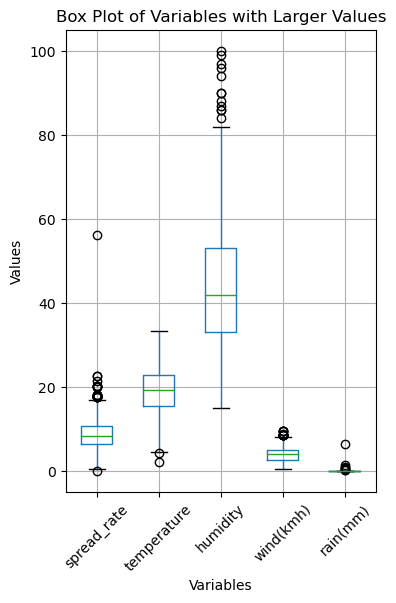

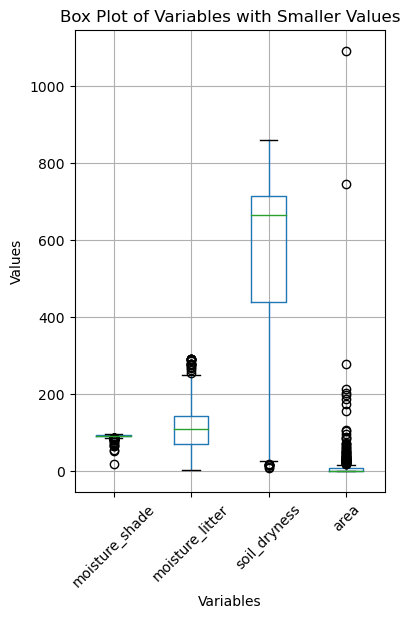

In [5]:
#Outliers
print(" ")
print("4: Outliers")

# Define the variables with larger values
large_scale_vars = ['spread_rate', 'temperature', 'humidity', 'wind(kmh)', 'rain(mm)']
# Create box plots for variables with larger values
plt.figure(figsize=(4, 6))
data[large_scale_vars].boxplot()
plt.title('Box Plot of Variables with Larger Values')
plt.xlabel('Variables')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.show()
print(" ")

# Define the variables with smaller values
small_scale_vars = ['moisture_shade', 'moisture_litter', 'soil_dryness', 'area']
# Create box plots for variables with smaller values
plt.figure(figsize=(4, 6))
data[small_scale_vars].boxplot()
plt.title('Box Plot of Variables with Smaller Values')
plt.xlabel('Variables')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.show()
print(" ")

#### Question 1c <span style="color:red">(20 marks)</span>
Use approporate methods to address the issues identified in <b>Q1a</b>.</span> Brielfy explain the methods and their parameters you used to address the issues.<br>

<b>Q1c answer</b>: 

Addressing '1. Missing Values'

Values 'day' and 'humidity' no longer have any missing values after dropping them with the 'dropna.()' function

In [6]:
#1. Missing Values

#dropping the rows/columns with any number of missing data
data_clean = data.dropna() 

#checks 'data_clean' for any missing values, there are no missing values
print(" ")
print(data_clean.isnull().sum()) 
print(" ")

 
coordinate_x       0
coordinate_y       0
month              0
day                0
moisture_shade     0
moisture_litter    0
soil_dryness       0
spread_rate        0
temperature        0
humidity           0
wind(kmh)          0
rain(mm)           0
area               0
dtype: int64
 


Addressing '4. Outliers'

As there are a significant amount of outliers in the dataset, if we were to remove them all then they would heavily impact the dataset, dramatically reducing its size. Therefore, to avoid any drastic immediate changes, we can remove only the extreme outliers which retains most of the dataset's information. Finding the interquartile range to detect and remove outliers offers a balanced trade-off between data preservation and noise reduction.

In [7]:
# 4. Outliers 

# calculates the quartiles and IQR for numeric columns only
# uses the 'select_dtypes' method with the parameter 'include=['number']
# this ensures that only numerical features are considered for outlier detection
numeric_cols = data_clean.select_dtypes(include=['number']).columns
# calculates the first quartile, third quartile and interquartile range for each numeric column
Q1 = data_clean[numeric_cols].quantile(0.25)
Q3 = data_clean[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# defines lower and upper bounds for outliers for each column
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# removes any extreme outliers for numeric columns only
# applies a boolean mask (((data_clean[numeric_cols] >= lower_bound) & (data_clean[numeric_cols] <= upper_bound)))
# this removes any rows from the dataset where the values in the numeric columns are outisde the calculated bounds
# it selects only the rows where all conditions are true (all(axis=1)).
data_clean_n = data_clean[((data_clean[numeric_cols] >= lower_bound) & (data_clean[numeric_cols] <= upper_bound)).all(axis=1)]

print(" ")

Addressing '2. Categorical Data'

The 'month' and 'day' columns both have categorical data and not numerical data. Dropping these two columns will improve the computational efficiency of the linear regression model as they are not relevant for the regression analysis. It will reduce the complexity of the analysis conduction.

In [8]:
# 2. Categorical Data

# 'data_clean_n.drop(['month','day'], axis=1): This part of the code calls the drop() method on the DataFrame data_clean_n.'
# it specifies the columns to be dropped using the ['month','day'] list. 
# 'axis=1' parameter indicates that columns are being dropped (as opposed to rows, which would be axis=0). 
# the result of the drop() operation is assigned to a new DataFrame called data_clean_new.
data_clean_new = data_clean_n.drop(['month','day'], axis=1)
print(" ")

Addressing '3. Variable Scaling'

In [9]:
# 3. Variable Scaling

# imports the MinMaxScaler class - allows us to scale features to a range (0-1)
from sklearn.preprocessing import MinMaxScaler

# calculates the minimum and maximum values of the data
# creates an instance of the MinMaxScaler and fits it to the data in the dataset which will be used for scaling
norm = MinMaxScaler().fit(data_clean_new) 

# scales the data using the scaler to [0,1]
arr = norm.transform(data_clean_new)

# creates a new dataframe from the scaled NumPy array
data_clean_scaled = pd.DataFrame(arr, columns=data_clean_new.columns) 

# prints the summary statistics of the new scaled dataset
print(" ")
print("New Dataset 'Fores_Fires_Area'")

data_clean_scaled.describe()

 
New Dataset 'Fores_Fires_Area'


,coordinate_x,coordinate_y,moisture_shade,moisture_litter,soil_dryness,spread_rate,temperature,humidity,wind(kmh),rain(mm),area
count,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.0,313.000000
mean,0.467252,0.471778,0.562524,0.412306,0.683644,0.408513,0.468195,0.404416,0.438961,0.0,0.141373
std,0.270264,0.301944,0.181300,0.223921,0.288549,0.224163,0.196845,0.199640,0.208282,0.0,0.227064
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,0.250000,0.333333,0.480000,0.301540,0.599599,0.255639,0.344262,0.268657,0.236842,0.0,0.000000
50%,0.500000,0.333333,0.560000,0.400770,0.807200,0.360902,0.471311,0.373134,0.421053,0.0,0.000000
75%,0.625000,0.666667,0.660000,0.523524,0.868916,0.518797,0.598361,0.522388,0.592105,0.0,0.195958
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000


Histogram:

 
Visualising the data: Histograms for the 'Forest_Fires_Area' dataset


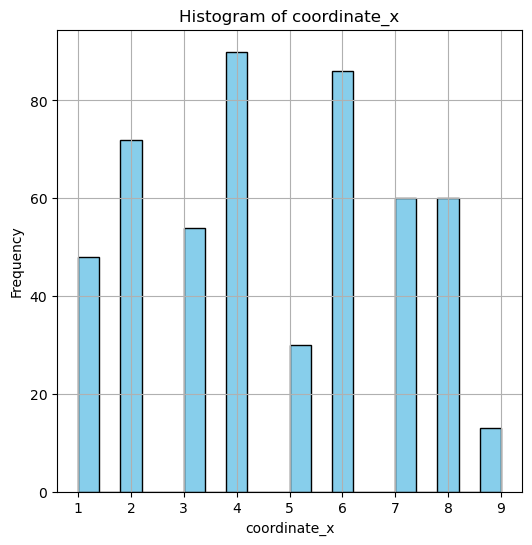

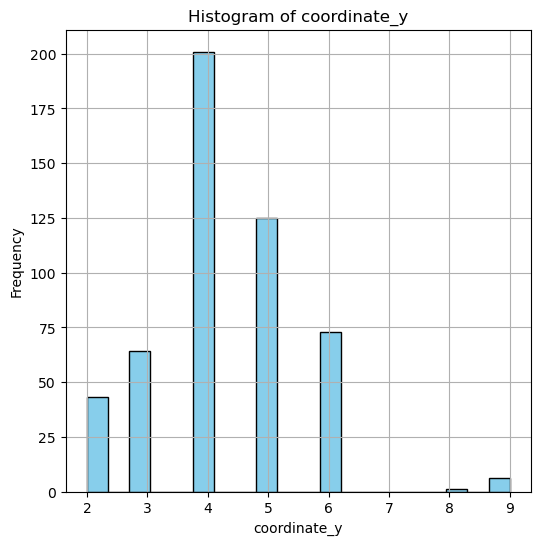

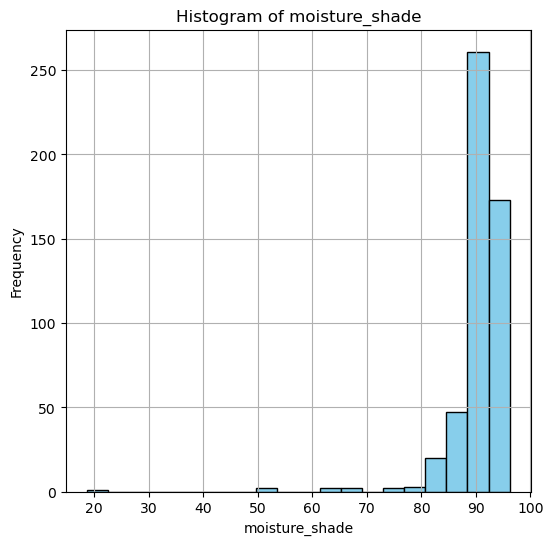

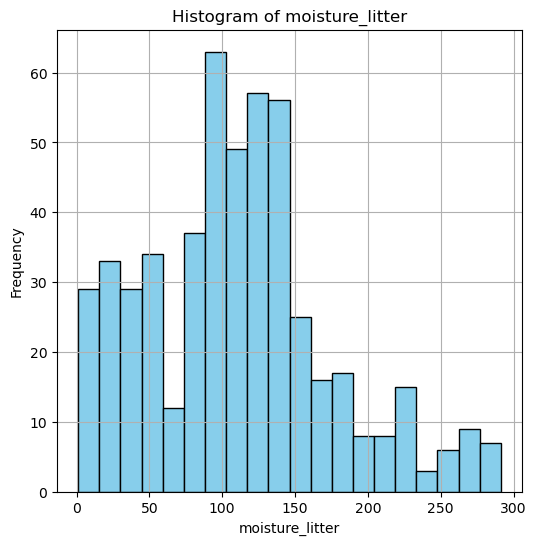

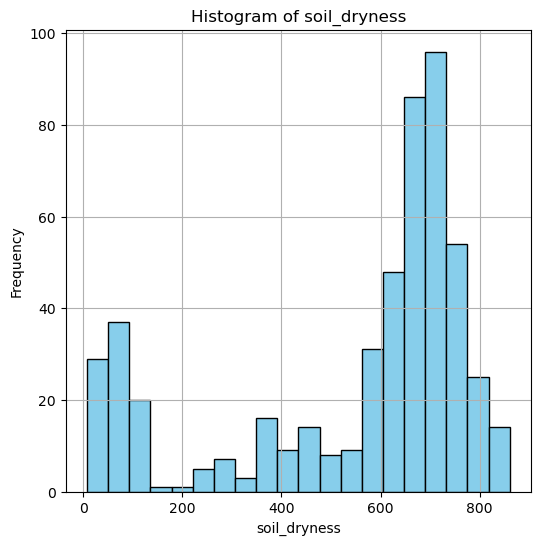

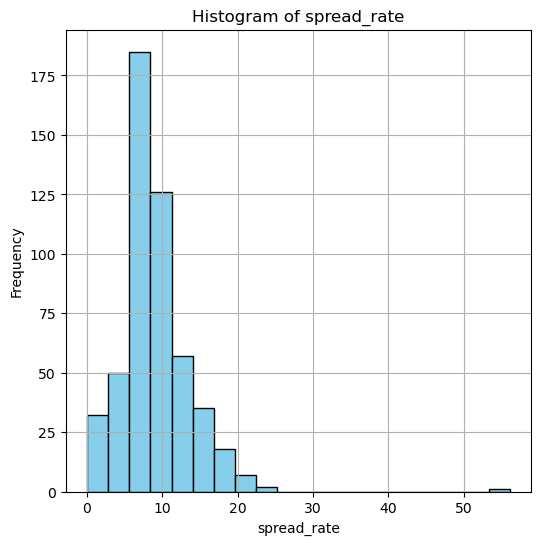

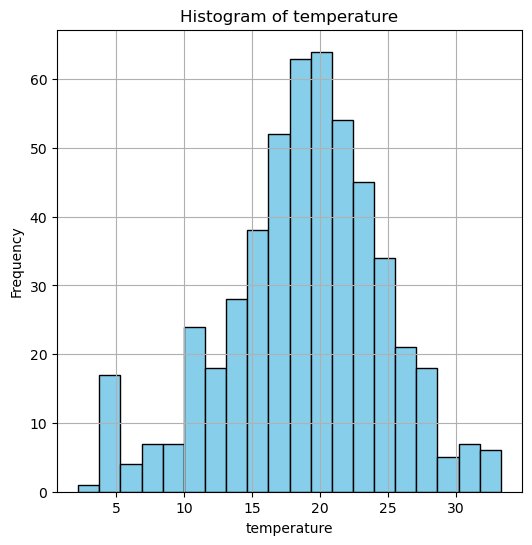

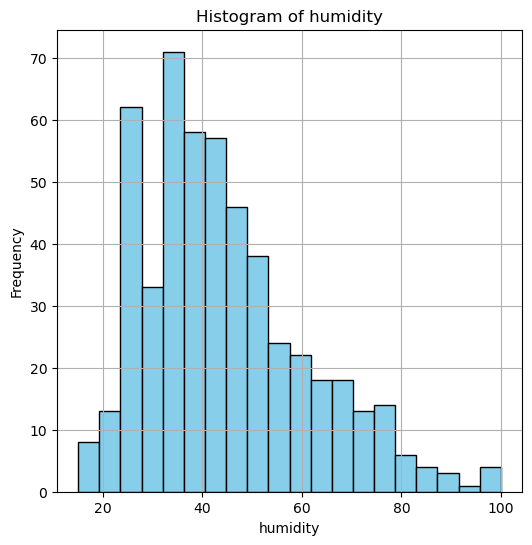

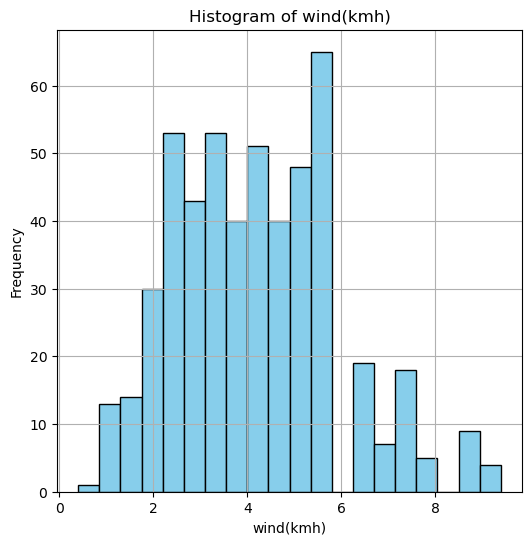

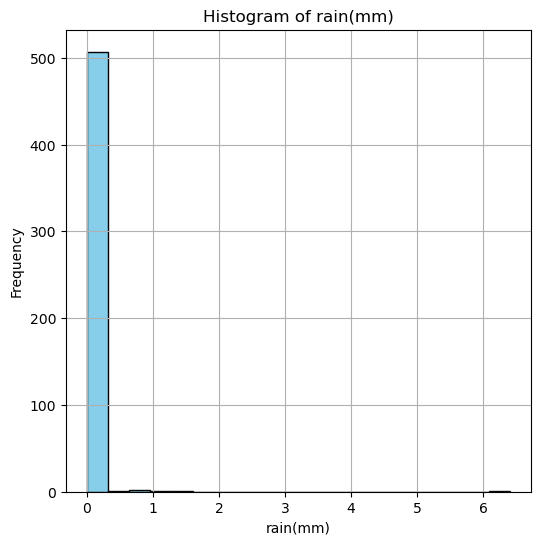

In [10]:
#HISTOGRAM

print(" ")
print("Visualising the data: Histograms for the 'Forest_Fires_Area' dataset")

#Select only numerical columns for histogram plotting
numerical_cols = ['coordinate_x', 'coordinate_y', 'moisture_shade', 'moisture_litter', 
                  'soil_dryness', 'spread_rate', 'temperature', 'humidity', 'wind(kmh)', 
                  'rain(mm)']

# Plot histograms for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(6, 6))
    plt.hist(data_clean[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()
print(" ")

#### Question 1d <span style="color:red">(10 marks)</span>
Build and train a linear regression model. Print its weights and accuracy. Which is the most important feature and how to interpret its contribution to your prediction?

<b>Q1d answer</b>: 

Building and training a linear regression model:

In [11]:
# building and training a linear regression model

# importing libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression

# splits the data into features (X) 
# and target variable (y)
X = data_clean_scaled.drop(columns=['area']) # features
y = data_clean_scaled['area'] # target variable

# splits the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# initializes and trains the linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predicts using the linear model on the testing data
y_pred = lr.predict(X_test)

In [12]:
# prints its weight

print(" ")
print(" Printing its weights: ")
print('Coefficient/slope:', lr.coef_)
print("")


print('The linear regression function learned between x an y is: y =', lr.intercept_, '+', lr.coef_[0], '* coordinate_x', 
      '+', lr.coef_[1], '* coordinate_y', '+', lr.coef_[2], '* moisture_shade', '+', lr.coef_[3], '* moisture_litter', 
      '+', lr.coef_[4], '* soil_dryness', '+', lr.coef_[5], '* spread_rate', '+', lr.coef_[6], '* temperature', 
      '+', lr.coef_[7], '* humidity', '+', lr.coef_[8], '* wind(kmh)', '+', lr.coef_[9], '* rain(mm)')


 
 Printing its weights: 
Coefficient/slope: [-0.07411186  0.07871664 -0.03032404  0.02153887  0.01770702  0.0758458
  0.09233717  0.12510949 -0.08040306  0.        ]

The linear regression function learned between x an y is: y = 0.04430915316968505 + -0.07411186479394874 * coordinate_x + 0.07871663716820569 * coordinate_y + -0.03032403823281805 * moisture_shade + 0.021538867909697022 * moisture_litter + 0.01770702343229185 * soil_dryness + 0.07584579775999042 * spread_rate + 0.09233717368733552 * temperature + 0.1251094886167344 * humidity + -0.08040306081280436 * wind(kmh) + 0.0 * rain(mm)


In [13]:
# prints its accuracy

print(" ")
print(" Printing its accuracy: ")
print("Mean Squared Error (Neural Networks):", metrics.mean_squared_error(y_test, y_pred))
print("")

 
 Printing its accuracy: 
Mean Squared Error (Neural Networks): 0.05606553012328749



In [14]:
# prints the most and least important feature of the dataset

# most important feature
print(" ")
coefficients = lr.coef_
absolute_coefficients = abs(coefficients)
most_important_feature_index = np.argmax(absolute_coefficients)
most_important_feature_name = X.columns[most_important_feature_index]

print("Most important feature:", most_important_feature_name)

# least important feature
coefficients = lr.coef_
absolute_coefficients = abs(coefficients)
least_important_feature_index = np.argmin(absolute_coefficients)
least_important_feature_name = X.columns[least_important_feature_index]

print("Least important feature:", least_important_feature_name)

 
Most important feature: humidity
Least important feature: rain(mm)


The most important feature is humidity. Humidity initially was one of the features that had two values missing and in the previous step, the two missing values were dropped. This perhaps may have affected the distribution of data and influenced the importance of features. However, the fact that humidity emerged as the most important feature suggests that it may be a crucial predictor in the dataset. A higher humidity level may have a significant impact on the likelihood or severity of forest fires. This implies that variations in humidity can have a reasonable influence on predicting forest fire area.

<div class="alert alert-success" style="text-align:left;"><h2>Question 2. Prediction Model 2<span style="float:right;">[20 marks]</span></h2></div>

#### Question 2a <span style="color:red">(10 marks)</span>
For the same dataset, build a different machine learning model for your prediction task.<br>
Which model did you choose and why? What are the parameters of your Prediction Model 2?</span>

<b>Q2a answer</b>: 

Prediction Model 2: Neural Networks

I chose Neural Networks because this machine learning model has the capability of capturing more detailed relationships between variables in data compared to linear regression models for both linear and nonlinear relationships. This allows for better performance and greater accuracy whilst being more efficient at the same time. 'The Forest_Fires_Area' dataset contains several variables and neural networks will be a more efficient method compared to the linear regression model for this particular prediction task. Neural networks can also process larger datasets than linear regression which may struggle with this high-dimensional data. This dataset contains a lot of variables and variable values which makes it more suitable to build a neural network as it can handle thousands of features and make millions of observations in a shorter span of time. This links with model complexity as neural networks can be scaled to have a larger number of parameters, allowing them to represent highly complex functions which linear regression may struggle to handle. Additionally, neural networks do not assume a linear relationship, they can model complex, non-linear relationships between inputs and outputs which allows them to capture more patterns in the data increasing the accuracy of the model.This is why I chose to build a neural network for this prediction task.

In [15]:
# import all required libraries
# import all required libraries from scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


# builds and trains the MLP regression model
# hidden_layer_sizes: specifies two hidden layers with 10 and 20 neurons
# max_iter: sets the maximum number of iterations for training to 8000
mlp = MLPRegressor(hidden_layer_sizes=(10, 20), max_iter=8000, random_state=1)
mlp.fit(X_train, y_train)

# Use the trained model to predict labels for the test data ('X_test')
mlp_y_predict = mlp.predict(X_test)

#### Question 2b <span style="color:red">(10 marks)</span>
Evaluate the model you built. Explain if this model is better or worse than Prediction Model 1, and in which way.

<b>Q2b answer</b>: 

The mean squared error for the Linear Regression model is approximately 0.0561.
The mean squared error for the Neural Networks model is approximately 0.0548.

A lower MSE values indicate better performance because they suggest that the model's predictions are closer to the actual values. Comparing the MSE values, we can see that the Neural Networks model has a slightly lower MSE compared to the Linear Regression model. Therefore, based on the MSE metric alone, the Neural Networks model performs slightly better in terms of prediction accuracy. This suggests that this model is better than the 1st prediction model and supports the statement I made in (2a) stating that neural networks are more accurate than linear regression models due to its ability to handle higher, more complex data. 

However, while MSE is used frequently for regression tasks, it is beneficial to consider other evaluation metrics in addition, such as the R-squared value, the mean absolute error (MAE) for both models which will allow for a more holistic comparison but comprehensive understanding.

Although the neural network model appears to be greater in prediciton accuracy, they are less interpretable which makes it challenging to understand how the model arrived at its prediction. Whereas with a linear regression model, the relationship sbetween the features and the 'area' for example can be explicitly represented by the coefficients assigned to each feature which makes a linear regression more interpretable and easier to understand. 

In [16]:
# Calculate Mean Squared Error (MAE)
print("")
print("Mean Squared Error (Linear Regression):", metrics.mean_squared_error(y_test, y_pred))
#print("Accuracy (Linear Regression):", metrics.r2_score(y_test, y_pred))
print("")

# Calculate the mean squared error to evaluate the model's performance
print("Mean Squared Error (Neural Networks):", metrics.mean_squared_error(y_test, mlp_y_predict))
#print("Accuracy (Linear Regression):", metrics.r2_score(y_test, mlp_y_predict))
print("")


Mean Squared Error (Linear Regression): 0.05606553012328749

Mean Squared Error (Neural Networks): 0.05481671127377458



<div class="alert alert-success" style="text-align:left;"><h2>Question 3. Comparison and Improvement<span style="float:right;">[30 marks]</span></h2></div>

#### Question 3a <span style="color:red">(15 marks)</span>
Based on your Prediction Model 1, remove the least important feature and evaluate the performance of the linear regression model. In which way the feature removal impacts the model performance?

<b>Q3a answer</b>:

The MSE for Model 1 (Linear Regression): 0.05606553012328749.

After removing the least important feature (rain(mm)) and evaluating the modified Linear Regression model, which has a new MSE: 0.05037500693630928, there is a decrease in the MSE to 0.05037500693630928.

This decrease in MSE suggests that the modified model with the removed feature has a better performance at predicting the target variable compared to the original model. It has positively impacted the model performance, resulting in more accurate predictions.

In [17]:
# removing the least important feature: rain(mm)

# identifies the least important feature
# finds the index of the smallest absolute coefficient in the linear regression model (lr.coef_')
# assumes that smaller coefficients correspond to less important features
least_important_feature_index = np.argmin(np.abs(lr.coef_))  # Assuming coefficients are absolute
least_important_feature_name = data_clean_scaled.columns[least_important_feature_index]

# removes the least important feature from the dataset
data_modified = data_clean_scaled.drop(columns=[least_important_feature_name])

# retrains the linear regression model on the modified dataset
X_modified = data_modified.drop(columns=['area'])  # Assuming 'target_variable' is the target column
y_modified = data_modified['area']
lr_modified = LinearRegression().fit(X_modified, y_modified)

# evaluates the performance of the updated model
y_pred_modified = lr_modified.predict(X_modified)
mse_modified = mean_squared_error(y_modified, y_pred_modified)

print("Mean Squared Error (Modified Linear Regression):", mse_modified)

Mean Squared Error (Modified Linear Regression): 0.05037500693630928


#### Question 3b <span style="color:red">(15 marks)</span>
By referring to your above relevant observations, what would you suggest to do in the future to build better models for predicting on new data instances? Why?<br>
<b>Hint</b>: based on relevant analysis, feature selection, feature scaling and data processing (e.g. resolve imbalanced samples, errors and outliers, etc.) could all potentially improve the model by reducing training time, fixing overfitting and improving interpretability, etc. You can also explore external resources for other potential approaches or techniques.<br>
<b>Note</b>: Coding is optional here, but your answers should be supported by relevant analysis or justifications.

<b>Q3b answer</b>: 

After evaluating the whole process, I have come to a few conclusions. In the future, to build better models for predicting new data instances I will consider the refinement of feature selection. In this investigation, in (3a), the removal of the 'rain' feature, although created little change in the accuracy of the predicted model, was closer to actual model. This implies how the removal or addition of any feature, no matter how small or large its values seem to be will have some sort of effect on the model. However, it is important to identify which features will aid us in increasing accuracy as this will increase efficiency. Prioritization of the retainment of the most influential features that have a significant influence on the target variable. The 'rain' feature through the evaluation of data in (1d) was shown to be the least important feature and so its removal did not negatively affect the model as shown in the new model later in (3). Further techniques can be employed such as correlation analysis to identify the most informative features. This streamlines the dataset, reduces overfitting risks and enhances model interpretability. Analyzing the correlation between features and the target variable 'area' can help identify which features have the strongest relationship with the target. Features with higher correlation coefficients are more informative and can be prioritized for inclusion in the regression model. Therefore, this would be a good method to use to identify the most important and least important features relevant to the model, reducing training time. 

Secondly, enhanced feature scaling is necessary to ensure uniformity to the model fitting process. I uses the min-max scaling this investigation to promote convergence and model performance. However, one of the determining factors for which scaling method to use is the number of outliers present in the dataset. I used the min-max scaling in this investigation but compared to the standardization method, it is more sensitive to outliers and the 'Forest_Fires_Area' dataset had a significant amount of outliers. Therefore, this could have affected the model as the min_max scaling cannot handle outliers very well, resulting in possible loss of data or disproportionately influencing the scaling.

The use of the robust statistical methods such as interquartile range used in this investigation for outlier treatment was effective and is a good statistical method to address any data integrity issues. This is a useful method which can be applied to future datasets to handle any missing values, outliers or imbalanced samples. 

Additionally, the continuous assesment of model performance present in (1c) and (1d) of a linear regression model, a neural network model (2a) with a comparison of the two models (2b) and a improvised linear regression model in (3a) is a reliable way to determine the most suitable approach for the specific prediction task, which can increase accuracy of the predicted model.